# PX4 Phase 1 Closed-Loop PINN-MPC v1

This notebook uses the trained v16 closed-loop dynamics PINN as the prediction model for an upper-level MPC.

The MPC does **not** command motors or raw thrust. It optimizes PX4 offboard-style setpoints:

```text
position / velocity / yaw-offset setpoints -> PX4 cascaded controller -> vehicle state
```

This first MPC notebook runs entirely inside the learned model so we can verify the controller logic before connecting it to PX4/Gazebo online.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import glob
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


device: cuda
torch: 2.10.0+cu128


In [3]:
NOTEBOOK_REVISION = 'v1_pinn_mpc'
MANUAL_CHECKPOINT_PATH = ''  # Set manually if auto-search misses it.
CHECKPOINT_GLOBS = [
    '/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_diagnostics_training_v16/**/px4_closed_loop_diagnostics_dynamics_pinn_v16.pt',
    '/content/drive/MyDrive/**/px4_closed_loop_diagnostics_dynamics_pinn_v16.pt',
    '/content/**/px4_closed_loop_diagnostics_dynamics_pinn_v16.pt',
]

DT = 0.05
MPC_HORIZON = 60          # 3 seconds at 20 Hz
MPC_SAMPLES = 512         # works on T4; reduce to 128 on CPU
MPC_ELITES = 48
MPC_ITERS = 4
CONTROL_INTERVAL_STEPS = 4  # apply first 0.2 s of optimized sequence

# Setpoint bounds. Position references are local NED offsets around hover.
POS_LIMIT_M = 4.0
ALT_MIN_M = 20.0
ALT_MAX_M = 30.0
VEL_LIMIT_M_S = 0.8
VD_LIMIT_M_S = 0.35
YAW_OFFSET_LIMIT_DEG = 30.0
DELTA_POS_LIMIT_M = 0.35
DELTA_VEL_LIMIT_M_S = 0.15
DELTA_YAW_LIMIT_DEG = 4.0

COST = dict(
    pos=12.0,
    alt=18.0,
    vel=1.2,
    yaw=1.8,
    terminal_pos=32.0,
    terminal_alt=40.0,
    effort_pos=0.04,
    effort_vel=0.05,
    effort_yaw=0.03,
    smooth=0.08,
)


In [4]:
def find_checkpoint():
    if MANUAL_CHECKPOINT_PATH:
        p = Path(MANUAL_CHECKPOINT_PATH)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_CHECKPOINT_PATH not found: {p}')
    matches = []
    for pat in CHECKPOINT_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if p.exists()))
    if not matches:
        raise FileNotFoundError('No v16 PINN checkpoint found. Run the v16 diagnostics training notebook first or set MANUAL_CHECKPOINT_PATH.')
    return matches[-1]

CKPT_PATH = find_checkpoint()
print('CKPT_PATH:', CKPT_PATH)
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('revision:', ckpt.get('revision'))
print('dataset:', ckpt.get('dataset_dir'))
STATE_COLS = ckpt['state_cols']
ACTION_COLS = ckpt['action_cols']
TARGET_COLS = ckpt['target_cols']
FEATURE_COLS = ckpt['feature_cols']
print('state:', STATE_COLS)
print('action:', ACTION_COLS)
print('feature dim:', len(FEATURE_COLS))


CKPT_PATH: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_diagnostics_training_v16/20260509_224911/px4_closed_loop_diagnostics_dynamics_pinn_v16.pt
revision: v16_diagnostics
dataset: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_closed_loop_yawrel_block_dataset_v7_20260510_073654
state: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action: ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg']
feature dim: 38


In [5]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class Scaler:
    def __init__(self, payload):
        self.mean = torch.tensor(payload['mean'], dtype=torch.float32)
        self.std = torch.tensor(payload['std'], dtype=torch.float32).clamp_min(1e-8)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)

model_cfg = ckpt.get('model_config', {})
model = ResidualMLP(
    len(FEATURE_COLS), len(TARGET_COLS),
    hidden=int(model_cfg.get('hidden', 256)),
    depth=int(model_cfg.get('depth', 4)),
    dropout=float(model_cfg.get('dropout', 0.0)),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
x_scaler = Scaler(ckpt['x_scaler'])
y_scaler = Scaler(ckpt['y_scaler'])
state_index = {c: i for i, c in enumerate(STATE_COLS)}
target_index = {c: i for i, c in enumerate(TARGET_COLS)}
feature_index = {c: i for i, c in enumerate(FEATURE_COLS)}


In [6]:
def wrap_deg_np(x):
    return ((x + 180.0) % 360.0) - 180.0

def build_feature_matrix(states, actions, prev_actions, dt=DT):
    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    prev_actions = np.asarray(prev_actions, dtype=np.float32)
    if states.ndim == 1:
        states = states[None, :]
    if actions.ndim == 1:
        actions = actions[None, :]
    if prev_actions.ndim == 1:
        prev_actions = prev_actions[None, :]
    du = actions - prev_actions
    n = states.shape[0]
    cols = []
    for name in FEATURE_COLS:
        if name == 'dt_s':
            cols.append(np.full(n, dt, dtype=np.float32))
        elif name == 'x_yaw_sin':
            cols.append(np.sin(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name == 'x_yaw_cos':
            cols.append(np.cos(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name.startswith('x_'):
            col = name[2:]
            cols.append(states[:, state_index[col]])
        elif name.startswith('u_') and name.endswith('_sin'):
            col = name[2:-4]
            cols.append(np.sin(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_') and name.endswith('_cos'):
            col = name[2:-4]
            cols.append(np.cos(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_sin'):
            col = name[7:-4]
            cols.append(np.sin(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_cos'):
            col = name[7:-4]
            cols.append(np.cos(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_'):
            col = name[2:]
            cols.append(actions[:, ACTION_COLS.index(col)])
        elif name.startswith('prev_u_'):
            col = name[7:]
            cols.append(prev_actions[:, ACTION_COLS.index(col)])
        elif name.startswith('du_'):
            col = name[3:]
            vals = du[:, ACTION_COLS.index(col)]
            if col in ['ref_yaw_deg', 'ref_yaw_offset_deg']:
                vals = wrap_deg_np(vals)
            cols.append(vals)
        else:
            raise KeyError(f'Unsupported feature name: {name}')
    return np.stack(cols, axis=1).astype(np.float32)

@torch.no_grad()
def predict_delta(states, actions, prev_actions, dt=DT):
    X = build_feature_matrix(states, actions, prev_actions, dt)
    Xz = x_scaler.encode(X).to(device)
    dz = model(Xz)
    dy = y_scaler.decode(dz).cpu().numpy()
    return dy

def step_model(states, actions, prev_actions, dt=DT):
    dx = predict_delta(states, actions, prev_actions, dt)
    next_states = np.asarray(states, dtype=np.float32).copy() + dx.astype(np.float32)
    next_states[:, state_index['yaw_deg']] = wrap_deg_np(next_states[:, state_index['yaw_deg']])
    return next_states


In [7]:
def make_action(ref_n=0.0, ref_e=0.0, ref_alt=25.0, ref_vn=0.0, ref_ve=0.0, ref_vd=0.0, yaw_base_deg=90.0, yaw_offset_deg=0.0):
    # ref_down_m is NED down, so altitude 25 m -> down -25 m.
    values = {
        'ref_north_m': ref_n,
        'ref_east_m': ref_e,
        'ref_down_m': -ref_alt,
        'ref_north_m_s': ref_vn,
        'ref_east_m_s': ref_ve,
        'ref_down_m_s': ref_vd,
        'ref_yaw_deg': wrap_deg_np(yaw_base_deg + yaw_offset_deg),
        'ref_yaw_offset_deg': yaw_offset_deg,
    }
    return np.asarray([values[c] for c in ACTION_COLS], dtype=np.float32)

def clip_actions(actions, yaw_base_deg=90.0):
    a = np.asarray(actions, dtype=np.float32).copy()
    def col(name): return ACTION_COLS.index(name)
    a[..., col('ref_north_m')] = np.clip(a[..., col('ref_north_m')], -POS_LIMIT_M, POS_LIMIT_M)
    a[..., col('ref_east_m')] = np.clip(a[..., col('ref_east_m')], -POS_LIMIT_M, POS_LIMIT_M)
    alt = -a[..., col('ref_down_m')]
    alt = np.clip(alt, ALT_MIN_M, ALT_MAX_M)
    a[..., col('ref_down_m')] = -alt
    a[..., col('ref_north_m_s')] = np.clip(a[..., col('ref_north_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_east_m_s')] = np.clip(a[..., col('ref_east_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_down_m_s')] = np.clip(a[..., col('ref_down_m_s')], -VD_LIMIT_M_S, VD_LIMIT_M_S)
    a[..., col('ref_yaw_offset_deg')] = np.clip(a[..., col('ref_yaw_offset_deg')], -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG)
    a[..., col('ref_yaw_deg')] = wrap_deg_np(yaw_base_deg + a[..., col('ref_yaw_offset_deg')])
    return a

def action_sequence_from_nominal(nominal_action, horizon=MPC_HORIZON, samples=MPC_SAMPLES, std_scale=1.0, yaw_base_deg=90.0):
    seq = np.repeat(nominal_action[None, None, :], samples * horizon, axis=0).reshape(samples, horizon, -1)
    noise = np.zeros_like(seq)
    for name, sigma in [
        ('ref_north_m', 0.55), ('ref_east_m', 0.55), ('ref_down_m', 0.35),
        ('ref_north_m_s', 0.16), ('ref_east_m_s', 0.16), ('ref_down_m_s', 0.08),
        ('ref_yaw_offset_deg', 3.0),
    ]:
        noise[..., ACTION_COLS.index(name)] = np.random.normal(0.0, sigma * std_scale, size=(samples, horizon))
    # Smooth cumulative perturbations make physically gentler setpoint sequences.
    seq = seq + np.cumsum(noise, axis=1) * 0.12
    seq[:, 0, :] = nominal_action
    return clip_actions(seq, yaw_base_deg=yaw_base_deg)


In [8]:
def target_at_time(t):
    # A simple mission-style local task: hold, move north/east/up, yaw, then recover.
    if t < 3.0:
        return dict(n=0.0, e=0.0, alt=25.0, yaw_offset=0.0)
    if t < 8.0:
        return dict(n=2.0, e=1.5, alt=27.0, yaw_offset=10.0)
    if t < 13.0:
        return dict(n=-1.5, e=-1.0, alt=24.0, yaw_offset=-10.0)
    return dict(n=0.0, e=0.0, alt=25.0, yaw_offset=0.0)

def trajectory_targets(times):
    return [target_at_time(float(t)) for t in times]

def running_cost(states, actions, prev_actions, targets, yaw_base_deg=90.0):
    n = states[:, state_index['vel_north_m_s']]
    e = states[:, state_index['vel_east_m_s']]
    vd = states[:, state_index['vel_down_m_s']]
    alt = states[:, state_index['relative_altitude_m']]
    yaw = states[:, state_index['yaw_deg']]
    roll = states[:, state_index['roll_deg']]
    pitch = states[:, state_index['pitch_deg']]

    tgt_n = np.asarray([x['n'] for x in targets], dtype=np.float32)
    tgt_e = np.asarray([x['e'] for x in targets], dtype=np.float32)
    tgt_alt = np.asarray([x['alt'] for x in targets], dtype=np.float32)
    tgt_yaw = wrap_deg_np(yaw_base_deg + np.asarray([x['yaw_offset'] for x in targets], dtype=np.float32))

    ref_n = actions[:, ACTION_COLS.index('ref_north_m')]
    ref_e = actions[:, ACTION_COLS.index('ref_east_m')]
    ref_alt = -actions[:, ACTION_COLS.index('ref_down_m')]
    ref_yaw = actions[:, ACTION_COLS.index('ref_yaw_deg')]

    pos_cost = COST['pos'] * ((ref_n - tgt_n) ** 2 + (ref_e - tgt_e) ** 2)
    alt_cost = COST['alt'] * ((ref_alt - tgt_alt) ** 2)
    vel_cost = COST['vel'] * (n ** 2 + e ** 2 + vd ** 2)
    yaw_cost = COST['yaw'] * (wrap_deg_np(ref_yaw - tgt_yaw) / 10.0) ** 2
    att_cost = 0.2 * (roll ** 2 + pitch ** 2)
    effort = COST['effort_pos'] * (ref_n ** 2 + ref_e ** 2 + (ref_alt - 25.0) ** 2)
    effort += COST['effort_vel'] * np.sum(actions[:, [ACTION_COLS.index('ref_north_m_s'), ACTION_COLS.index('ref_east_m_s'), ACTION_COLS.index('ref_down_m_s')]] ** 2, axis=1)
    effort += COST['effort_yaw'] * (actions[:, ACTION_COLS.index('ref_yaw_offset_deg')] / 10.0) ** 2
    smooth = COST['smooth'] * np.mean((actions - prev_actions) ** 2, axis=1)
    return pos_cost + alt_cost + vel_cost + yaw_cost + att_cost + effort + smooth

def terminal_cost(states, target, yaw_base_deg=90.0):
    alt = states[:, state_index['relative_altitude_m']]
    yaw = states[:, state_index['yaw_deg']]
    # We use velocity-integrated local position as an external MPC state below; this terminal is mostly alt/yaw.
    tgt_yaw = wrap_deg_np(yaw_base_deg + target['yaw_offset'])
    return COST['terminal_alt'] * (alt - target['alt']) ** 2 + COST['yaw'] * (wrap_deg_np(yaw - tgt_yaw) / 10.0) ** 2


In [9]:
def evaluate_sequences(initial_state, initial_local_pos, prev_action, action_sequences, t0=0.0, yaw_base_deg=90.0):
    samples, horizon, _ = action_sequences.shape
    states = np.repeat(initial_state[None, :], samples, axis=0).astype(np.float32)
    local_pos = np.repeat(np.asarray(initial_local_pos, dtype=np.float32)[None, :], samples, axis=0)
    prev = np.repeat(prev_action[None, :], samples, axis=0).astype(np.float32)
    costs = np.zeros(samples, dtype=np.float32)
    for k in range(horizon):
        actions = action_sequences[:, k, :]
        times = t0 + (k + 1) * DT
        targets = trajectory_targets(np.full(samples, times))
        states = step_model(states, actions, prev, DT)
        local_pos[:, 0] += states[:, state_index['vel_north_m_s']] * DT
        local_pos[:, 1] += states[:, state_index['vel_east_m_s']] * DT
        # Add task tracking on integrated local position.
        tgt_n = np.asarray([x['n'] for x in targets], dtype=np.float32)
        tgt_e = np.asarray([x['e'] for x in targets], dtype=np.float32)
        costs += running_cost(states, actions, prev, targets, yaw_base_deg=yaw_base_deg)
        costs += COST['pos'] * ((local_pos[:, 0] - tgt_n) ** 2 + (local_pos[:, 1] - tgt_e) ** 2)
        prev = actions
    costs += terminal_cost(states, target_at_time(t0 + horizon * DT), yaw_base_deg=yaw_base_deg)
    return costs

def mppi_plan(initial_state, initial_local_pos, prev_action, t0=0.0, yaw_base_deg=90.0):
    target = target_at_time(t0)
    nominal = make_action(target['n'], target['e'], target['alt'], yaw_base_deg=yaw_base_deg, yaw_offset_deg=target['yaw_offset'])
    best_seq = np.repeat(nominal[None, :], MPC_HORIZON, axis=0)
    best_cost = float('inf')
    std_scale = 1.0
    for it in range(MPC_ITERS):
        seq = action_sequence_from_nominal(best_seq[0], MPC_HORIZON, MPC_SAMPLES, std_scale=std_scale, yaw_base_deg=yaw_base_deg)
        # Keep current best as an anchor.
        seq[0] = best_seq
        costs = evaluate_sequences(initial_state, initial_local_pos, prev_action, seq, t0=t0, yaw_base_deg=yaw_base_deg)
        elite_idx = np.argsort(costs)[:MPC_ELITES]
        elite = seq[elite_idx]
        best_seq = elite.mean(axis=0)
        best_seq = clip_actions(best_seq, yaw_base_deg=yaw_base_deg)
        best_cost = float(costs[elite_idx[0]])
        std_scale *= 0.72
    return best_seq, best_cost


In [10]:
def run_closed_loop_mpc(sim_time_s=16.0, yaw_base_deg=90.0):
    init_state = np.zeros(len(STATE_COLS), dtype=np.float32)
    init_state[state_index['relative_altitude_m']] = 25.0
    init_state[state_index['vel_north_m_s']] = 0.0
    init_state[state_index['vel_east_m_s']] = 0.0
    init_state[state_index['vel_down_m_s']] = 0.0
    init_state[state_index['roll_deg']] = 0.0
    init_state[state_index['pitch_deg']] = 0.0
    init_state[state_index['yaw_deg']] = yaw_base_deg
    init_state[state_index['roll_rate_rad_s']] = 0.0
    init_state[state_index['pitch_rate_rad_s']] = 0.0
    init_state[state_index['yaw_rate_rad_s']] = 0.0

    state = init_state.copy()
    local_pos = np.array([0.0, 0.0], dtype=np.float32)
    prev_action = make_action(0.0, 0.0, 25.0, yaw_base_deg=yaw_base_deg, yaw_offset_deg=0.0)
    logs = []
    plan = np.repeat(prev_action[None, :], CONTROL_INTERVAL_STEPS, axis=0)
    plan_cost = np.nan
    steps = int(sim_time_s / DT)
    t_plan_start = time.time()
    for step in range(steps):
        t = step * DT
        if step % CONTROL_INTERVAL_STEPS == 0:
            plan, plan_cost = mppi_plan(state, local_pos, prev_action, t0=t, yaw_base_deg=yaw_base_deg)
        action = plan[min(step % CONTROL_INTERVAL_STEPS, len(plan) - 1)]
        next_state = step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0]
        local_pos[0] += next_state[state_index['vel_north_m_s']] * DT
        local_pos[1] += next_state[state_index['vel_east_m_s']] * DT
        tgt = target_at_time(t)
        logs.append({
            'time_s': t,
            'north_m': float(local_pos[0]),
            'east_m': float(local_pos[1]),
            'alt_m': float(next_state[state_index['relative_altitude_m']]),
            'yaw_deg': float(next_state[state_index['yaw_deg']]),
            'roll_deg': float(next_state[state_index['roll_deg']]),
            'pitch_deg': float(next_state[state_index['pitch_deg']]),
            'vn_m_s': float(next_state[state_index['vel_north_m_s']]),
            've_m_s': float(next_state[state_index['vel_east_m_s']]),
            'vd_m_s': float(next_state[state_index['vel_down_m_s']]),
            'ref_north_m': float(action[ACTION_COLS.index('ref_north_m')]),
            'ref_east_m': float(action[ACTION_COLS.index('ref_east_m')]),
            'ref_alt_m': float(-action[ACTION_COLS.index('ref_down_m')]),
            'ref_vn_m_s': float(action[ACTION_COLS.index('ref_north_m_s')]),
            'ref_ve_m_s': float(action[ACTION_COLS.index('ref_east_m_s')]),
            'ref_vd_m_s': float(action[ACTION_COLS.index('ref_down_m_s')]),
            'ref_yaw_offset_deg': float(action[ACTION_COLS.index('ref_yaw_offset_deg')]),
            'target_north_m': tgt['n'],
            'target_east_m': tgt['e'],
            'target_alt_m': tgt['alt'],
            'target_yaw_offset_deg': tgt['yaw_offset'],
            'plan_cost': plan_cost,
        })
        prev_action = action
        state = next_state
    print('closed-loop learned-model MPC elapsed s:', round(time.time() - t_plan_start, 2))
    return pd.DataFrame(logs)

mpc_log = run_closed_loop_mpc(sim_time_s=16.0)
display(mpc_log.head())
display(mpc_log.tail())


closed-loop learned-model MPC elapsed s: 40.04


,time_s,north_m,east_m,alt_m,yaw_deg,roll_deg,pitch_deg,vn_m_s,ve_m_s,vd_m_s,...,ref_alt_m,ref_vn_m_s,ref_ve_m_s,ref_vd_m_s,ref_yaw_offset_deg,target_north_m,target_east_m,target_alt_m,target_yaw_offset_deg,plan_cost
0,0.00,-0.000074,-0.000048,24.999411,90.004181,-0.005996,-0.002121,-0.001483,-0.000969,0.000358,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,25.0,0.0,830.905945
1,0.05,-0.000069,-0.000106,24.982803,89.971191,0.120165,-0.322235,0.000101,-0.001143,-0.013331,...,25.004419,0.001873,-0.002109,-0.000059,-0.040725,0.0,0.0,25.0,0.0,830.905945
2,0.10,0.000015,-0.000171,24.966196,89.938141,0.246308,-0.642228,0.001681,-0.001314,-0.027019,...,25.002998,0.002264,-0.001392,-0.000767,-0.006396,0.0,0.0,25.0,0.0,830.905945
3,0.15,0.000178,-0.000245,24.949589,89.905060,0.372443,-0.962011,0.003255,-0.001473,-0.040706,...,25.003654,0.001940,-0.000272,-0.001521,0.011790,0.0,0.0,25.0,0.0,830.905945
4,0.20,-0.000243,-0.001442,24.948833,89.905853,0.397078,-0.755233,-0.008411,-0.023940,-0.047650,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,25.0,0.0,1955.461670


,time_s,north_m,east_m,alt_m,yaw_deg,roll_deg,pitch_deg,vn_m_s,ve_m_s,vd_m_s,...,ref_alt_m,ref_vn_m_s,ref_ve_m_s,ref_vd_m_s,ref_yaw_offset_deg,target_north_m,target_east_m,target_alt_m,target_yaw_offset_deg,plan_cost
315,15.75,-8.943065,-18.027866,21.537817,83.092102,24.088242,-43.126286,-1.027542,-2.134742,-3.667705,...,25.000328,0.000506,0.001133,-0.000281,0.031013,0.0,0.0,25.0,0.0,432256.21875
316,15.80,-8.995037,-18.135714,21.537098,83.092834,24.108082,-42.917999,-1.039450,-2.156938,-3.674577,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,25.0,0.0,448402.00000
317,15.85,-9.046931,-18.243547,21.520700,83.059235,24.226675,-43.234341,-1.037885,-2.156680,-3.688424,...,25.001602,0.002048,-0.002171,-0.000047,0.027654,0.0,0.0,25.0,0.0,448402.00000
318,15.90,-9.098749,-18.351336,21.504614,83.024658,24.334084,-43.544979,-1.036350,-2.155776,-3.702504,...,24.998507,0.003296,-0.001828,-0.000616,0.011181,0.0,0.0,25.0,0.0,448402.00000
319,15.95,-9.150489,-18.459101,21.488317,82.990723,24.449049,-43.859348,-1.034798,-2.155302,-3.716424,...,24.999125,0.002156,-0.001305,0.000125,0.053690,0.0,0.0,25.0,0.0,448402.00000


,pos_rmse_m,pos_final_err_m,alt_rmse_m,alt_final_err_m,yaw_rmse_deg,yaw_final_err_deg,max_abs_roll_deg,max_abs_pitch_deg
0,9.090277,20.602666,2.373862,-3.511683,8.126563,-7.009277,24.449049,43.859348


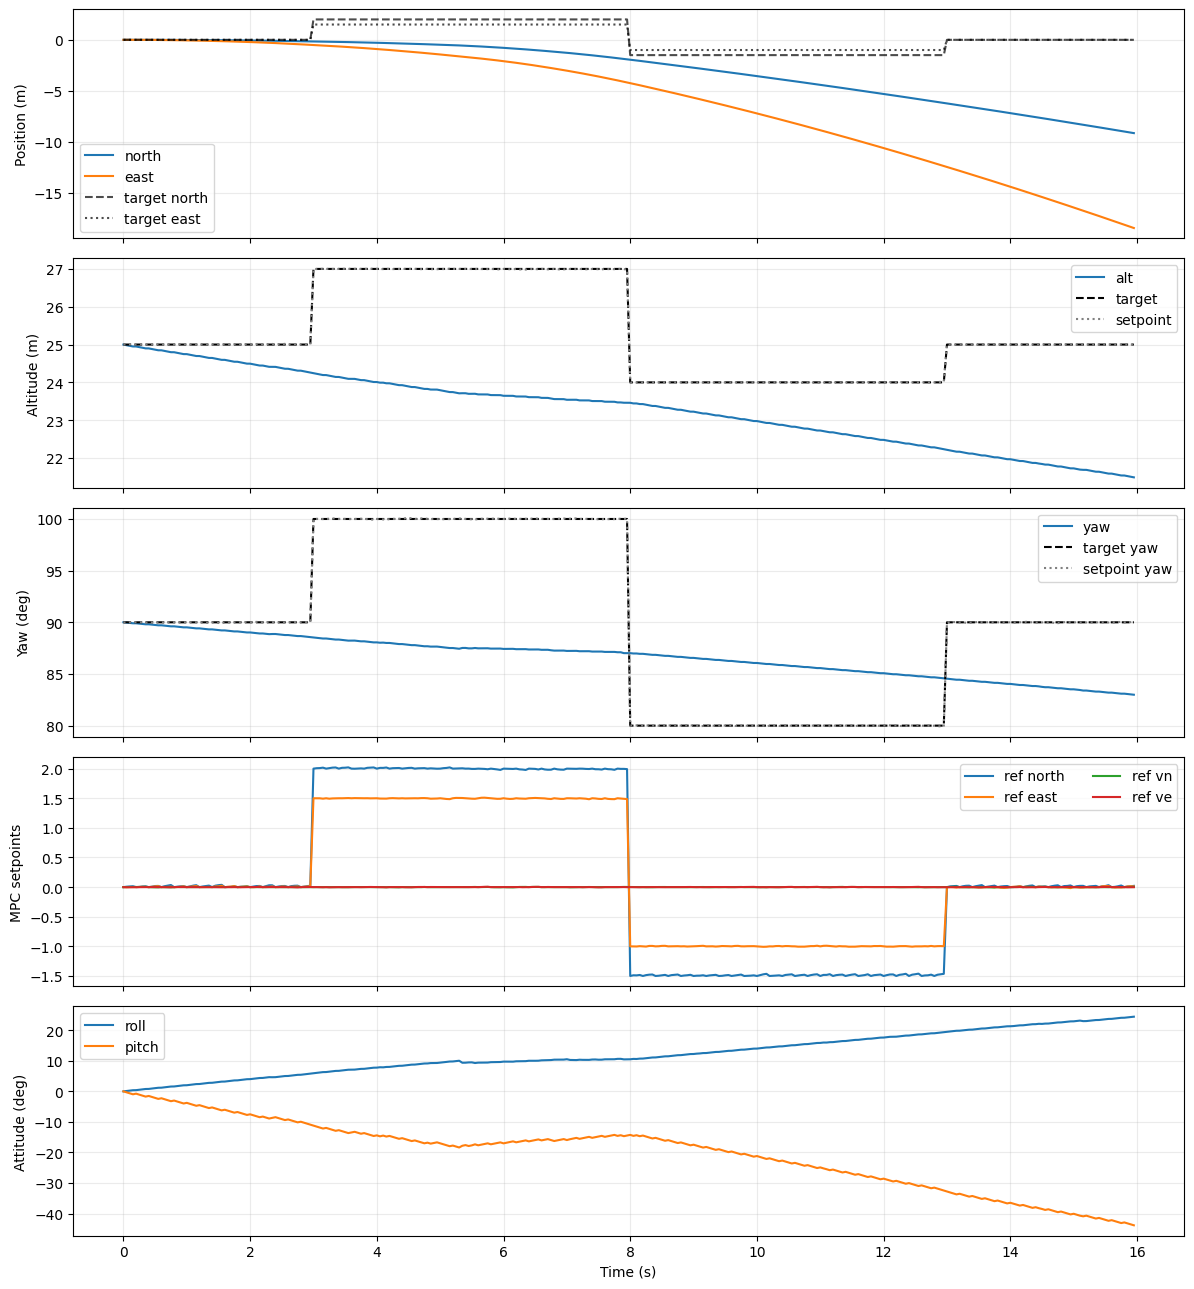

In [11]:
def compute_mpc_metrics(log):
    pos_err = np.sqrt((log['north_m'] - log['target_north_m']) ** 2 + (log['east_m'] - log['target_east_m']) ** 2)
    alt_err = log['alt_m'] - log['target_alt_m']
    yaw_err = wrap_deg_np(log['yaw_deg'].to_numpy() - (90.0 + log['target_yaw_offset_deg'].to_numpy()))
    return pd.DataFrame([{
        'pos_rmse_m': float(np.sqrt(np.mean(pos_err ** 2))),
        'pos_final_err_m': float(pos_err.iloc[-1]),
        'alt_rmse_m': float(np.sqrt(np.mean(alt_err ** 2))),
        'alt_final_err_m': float(alt_err.iloc[-1]),
        'yaw_rmse_deg': float(np.sqrt(np.mean(yaw_err ** 2))),
        'yaw_final_err_deg': float(yaw_err[-1]),
        'max_abs_roll_deg': float(np.max(np.abs(log['roll_deg']))),
        'max_abs_pitch_deg': float(np.max(np.abs(log['pitch_deg']))),
    }])

mpc_metrics = compute_mpc_metrics(mpc_log)
display(mpc_metrics)

fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)
t = mpc_log['time_s']
axes[0].plot(t, mpc_log['north_m'], label='north')
axes[0].plot(t, mpc_log['east_m'], label='east')
axes[0].plot(t, mpc_log['target_north_m'], 'k--', alpha=0.7, label='target north')
axes[0].plot(t, mpc_log['target_east_m'], 'k:', alpha=0.7, label='target east')
axes[0].set_ylabel('Position (m)')
axes[0].legend()

axes[1].plot(t, mpc_log['alt_m'], label='alt')
axes[1].plot(t, mpc_log['target_alt_m'], 'k--', label='target')
axes[1].plot(t, mpc_log['ref_alt_m'], '0.5', ls=':', label='setpoint')
axes[1].set_ylabel('Altitude (m)')
axes[1].legend()

axes[2].plot(t, mpc_log['yaw_deg'], label='yaw')
axes[2].plot(t, 90.0 + mpc_log['target_yaw_offset_deg'], 'k--', label='target yaw')
axes[2].plot(t, 90.0 + mpc_log['ref_yaw_offset_deg'], '0.5', ls=':', label='setpoint yaw')
axes[2].set_ylabel('Yaw (deg)')
axes[2].legend()

axes[3].plot(t, mpc_log['ref_north_m'], label='ref north')
axes[3].plot(t, mpc_log['ref_east_m'], label='ref east')
axes[3].plot(t, mpc_log['ref_vn_m_s'], label='ref vn')
axes[3].plot(t, mpc_log['ref_ve_m_s'], label='ref ve')
axes[3].set_ylabel('MPC setpoints')
axes[3].legend(ncol=2)

axes[4].plot(t, mpc_log['roll_deg'], label='roll')
axes[4].plot(t, mpc_log['pitch_deg'], label='pitch')
axes[4].set_ylabel('Attitude (deg)')
axes[4].set_xlabel('Time (s)')
axes[4].legend()
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


In [12]:
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v1')
else:
    SAVE_ROOT = Path('/content/px4_phase1_closed_loop_pinn_mpc_v1')
SAVE_DIR = SAVE_ROOT / time.strftime('%Y%m%d_%H%M%S')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
mpc_log.to_csv(SAVE_DIR / 'pinn_mpc_learned_model_log.csv', index=False)
mpc_metrics.to_csv(SAVE_DIR / 'pinn_mpc_learned_model_metrics.csv', index=False)
fig.savefig(SAVE_DIR / 'pinn_mpc_learned_model_response.png', dpi=160, bbox_inches='tight')
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump({
        'revision': NOTEBOOK_REVISION,
        'checkpoint': str(CKPT_PATH),
        'horizon': MPC_HORIZON,
        'samples': MPC_SAMPLES,
        'elites': MPC_ELITES,
        'iters': MPC_ITERS,
        'control_interval_steps': CONTROL_INTERVAL_STEPS,
        'cost': COST,
    }, f, indent=2)
print('saved:', SAVE_DIR)


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v1/20260509_225941
